# Cohort Analysis for Customer Churn

## Objective
To analyze customer behavior by grouping users into cohorts and identifying patterns in churn across different segments.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [2]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

In [3]:
bins = [0, 12, 24, 48, 60, 100]
labels = ["0-12", "12-24", "24-48", "48-60", "60+"]

df["tenure_group"] = pd.cut(df["tenure"], bins=bins, labels=labels)

In [4]:
df["tenure_group"].value_counts()

tenure_group
0-12     2175
24-48    1594
60+      1407
12-24    1024
48-60     832
Name: count, dtype: int64

In [5]:
bins = [0, 35, 70, 100]
labels = ["Low", "Medium", "High"]

df["charges_group"] = pd.cut(df["MonthlyCharges"], bins=bins, labels=labels)

In [7]:
def churn_rate(data, group_col):
   return data.groupby(group_col)["Churn"].value_counts(normalize=True).unstack() * 100


In [8]:
tenure_churn = churn_rate(df, "tenure_group")
tenure_churn

C:\Users\vansh\AppData\Local\Temp\ipykernel_37696\2519295557.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return data.groupby(group_col)["Churn"].value_counts(normalize=True).unstack() * 100


Churn,No,Yes
tenure_group,,
0-12,52.321839,47.678161
12-24,71.289062,28.710938
24-48,79.611041,20.388959
48-60,85.576923,14.423077
60+,93.390192,6.609808


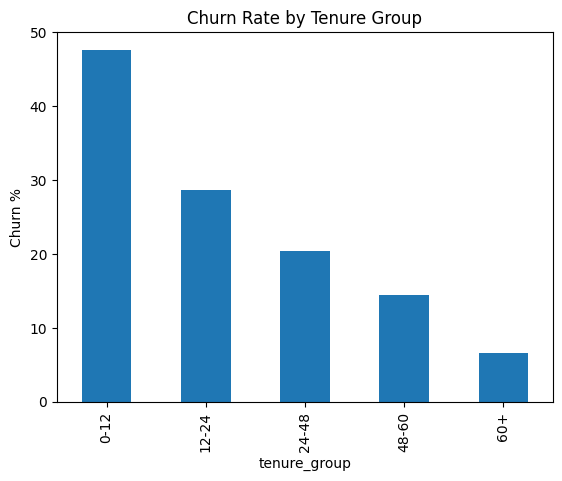

In [9]:
tenure_churn["Yes"].plot(kind="bar")
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Churn %")
plt.show()

## Insight: Tenure Cohort

Customers with lower tenure (0–12 months) have the highest churn rate.
This indicates that new customers are more likely to leave early.


In [10]:
contract_churn = churn_rate(df, "Contract")
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


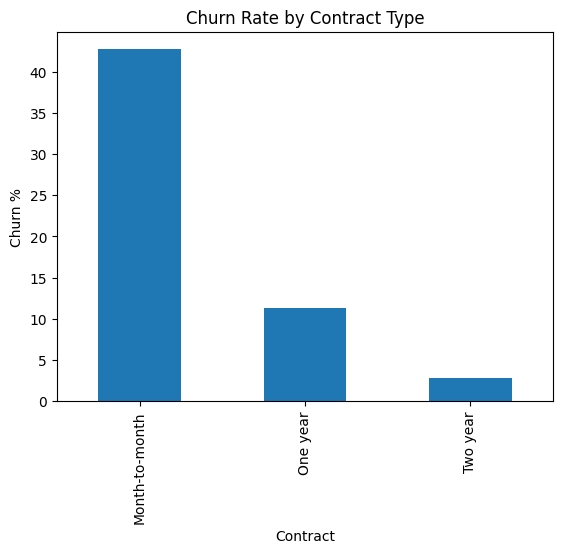

In [11]:
contract_churn["Yes"].plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn %")
plt.show()

## Insight: Contract Type

Customers with month-to-month contracts show significantly higher churn rates compared to yearly contracts.
Long-term contracts reduce churn risk.


In [12]:
charges_churn = churn_rate(df, "charges_group")
charges_churn

C:\Users\vansh\AppData\Local\Temp\ipykernel_37696\2519295557.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return data.groupby(group_col)["Churn"].value_counts(normalize=True).unstack() * 100


Churn,No,Yes
charges_group,,
Low,89.068826,10.931174
Medium,76.016260,23.983740
High,62.150056,37.849944


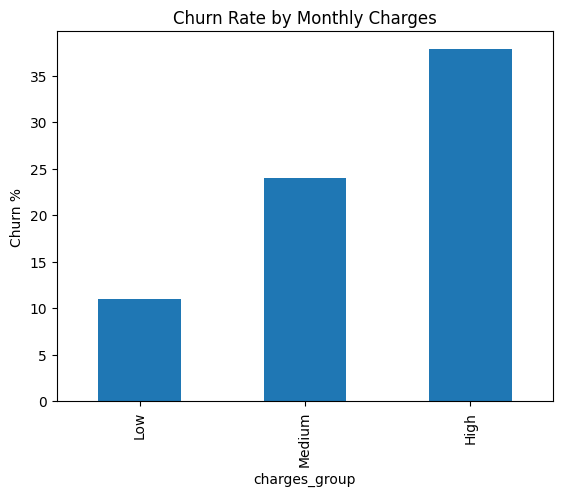

In [13]:
charges_churn["Yes"].plot(kind="bar")
plt.title("Churn Rate by Monthly Charges")
plt.ylabel("Churn %")
plt.show()

## Insight: Monthly Charges

Customers with higher monthly charges tend to have higher churn rates.
This suggests pricing may influence customer retention.


C:\Users\vansh\AppData\Local\Temp\ipykernel_37696\711964100.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  retention = df.groupby("tenure_group")["Churn"].value_counts(normalize=True).unstack()


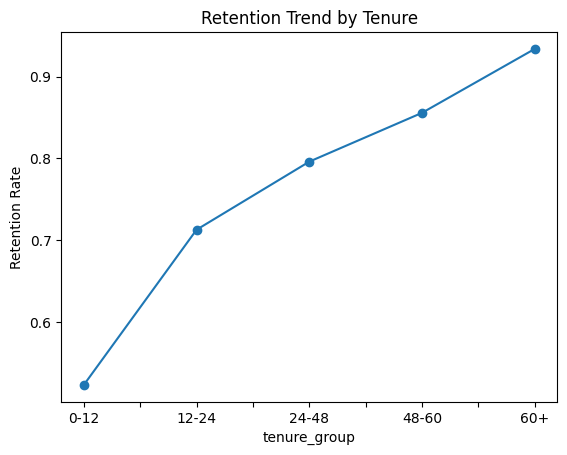

In [14]:
retention = df.groupby("tenure_group")["Churn"].value_counts(normalize=True).unstack()
retention["No"].plot(kind="line", marker="o")
plt.title("Retention Trend by Tenure")
plt.ylabel("Retention Rate")
plt.show()

## Retention Trend

Retention increases with tenure, indicating that long-term customers are more stable and less likely to churn.


## Business Insights

- New customers (0–12 months) are the most likely to churn → onboarding is critical
- Month-to-month contract users are high-risk customers
- High-paying customers show increased churn risk
- Retention improves significantly with tenure

These insights can help businesses design targeted retention strategies.
